In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
import sys

sys.path.append('..') 
sys.path.append('../..')
from models.mlp import MLP
from shared.utils.trainer import train_one_epoch, validate

In [5]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.12.0.dev20260218+cu128
True
NVIDIA GeForce RTX 5070 Ti


In [8]:
input_size = 28 * 28
hidden_sizes = [256, 128]
num_classes = 10
dropout_p = 0.3
learning_rate = 0.001
num_epochs = 10
batch_size = 64
data_dir = "../../data"

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

training_data = datasets.MNIST(
    root=data_dir,
    train= True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=transform
)

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


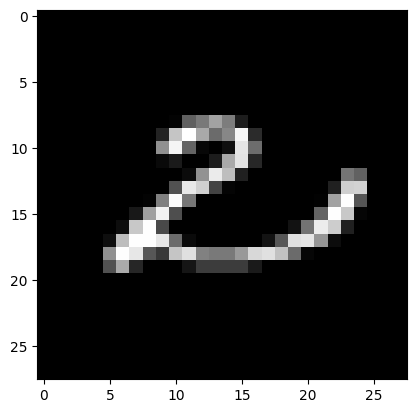

Label: 2


In [6]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

In [11]:
model = MLP(input_size, hidden_sizes, num_classes, dropout_p).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [12]:
train_losses, train_accs = [], []
val_losses, val_accs = [], []
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(model, train_dataloader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, test_dataloader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")



Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 275.69it/s]


Train Loss: 0.2881, Train Acc: 91.47%
Val Loss: 0.1301, Val Acc: 95.86%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 246.06it/s]


Train Loss: 0.1752, Train Acc: 94.65%
Val Loss: 0.1098, Val Acc: 96.82%

Epoch 3/10


...

Train Loss: 0.0959, Train Acc: 96.95%
Val Loss: 0.0824, Val Acc: 98.00%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 246.86it/s]


Train Loss: 0.0890, Train Acc: 97.09%
Val Loss: 0.0726, Val Acc: 98.05%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 274.30it/s]

Train Loss: 0.0873, Train Acc: 97.20%
Val Loss: 0.0704, Val Acc: 97.95%


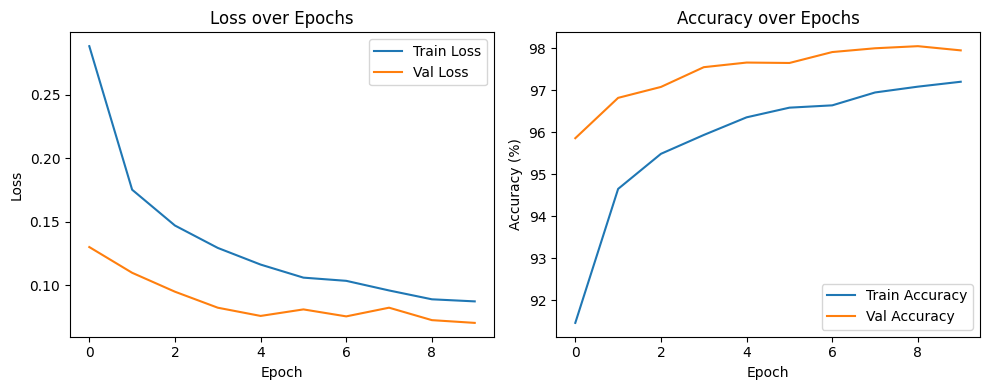

In [14]:
# Plot metrics and save the figure (saving in the same cell avoids blank images)
import os

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accs, label='Train Accuracy')
ax2.plot(val_accs, label='Val Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

fig.tight_layout()

os.makedirs('../results', exist_ok=True)
fig.savefig('../results/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()